# Spaltenweiser Vergleich: `rfd_main.csv` vs. `rfd_main_cleaned.csv`

Dieses Notebook vergleicht den Rohdatensatz und den von der Kaggle-Quelle
vorbereinigten Referenzdatensatz **systematisch, Spalte für Spalte**, um empirisch zu
belegen, *was* die vorgenommene Bereinigung tatsächlich verändert hat (vgl. Abschnitt
3.2, Vergleichsrahmen und Rolle des Referenzdatensatzes). Es ergänzt
`EDA_Datenexploration.ipynb` und `EDA_Datenexploration_cleaned.ipynb`, die beide
Datensätze bereits einzeln beschreiben - hier geht es um den direkten,
zeilengenauen Vergleich.

**Methodik:** Da die beiden CSV-Dateien keine gemeinsame ID-Spalte besitzen, wird die
in `01_Benchmark_und_GroundTruth_Erstellung.ipynb` erzeugte inhaltsbasierte Zuordnung
(`benchmark/raw_clean_row_mapping.csv`, Übereinstimmung von Titel + Autor + Zeitstempel,
97,5 % der Zeilen) wiederverwendet. Für jede Spalte wird geprüft:

1. Hat sich der **Datentyp** geändert (z. B. `object` -> `float64`)?
2. Hat sich der **Anteil fehlender Werte** geändert (Vervollständigung)?
3. Sind die Werte bei denselben (zugeordneten) Zeilen **inhaltlich identisch**, oder
   wurden sie umformatiert/transformiert?

**Ablauf:**
1. Setup und Laden der Daten
2. Automatisierte Spalte-für-Spalte-Analyse (alle 14 Spalten)
3. Zusammenfassende Übersichtstabelle und Visualisierung
4. Vertiefung: `source` (automatische Ableitung aus der URL-Domain)
5. Vertiefung: `saving` (Formatwechsel *und* abgeleitetes Verhältnis)
6. Vertiefung: Datumsspalten (reine Formatnormalisierung ohne Vervollständigung)
7. Fazit: Klassifikation aller Spalten


## 1. Setup und Laden der Daten

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 100

df_raw = pd.read_csv("data/rfd_main.csv").drop(columns=["Unnamed: 0"]).reset_index(drop=True)
df_raw["row_id"] = df_raw.index

df_clean = pd.read_csv("data/rfd_main_cleaned.csv").drop(columns=["Unnamed: 0"]).reset_index(drop=True)
df_clean["row_id"] = df_clean.index

row_mapping = pd.read_csv("benchmark/raw_clean_row_mapping.csv")

COLS = ["author", "creation_date", "expiry", "last_reply", "parent_category", "price",
        "replies", "saving", "source", "thread_category", "title", "url", "views", "votes"]

print(f"Rohdatensatz (rfd_main.csv):        {df_raw.shape[0]} Zeilen, {df_raw.shape[1] - 1} Spalten")
print(f"Referenzdatensatz (rfd_main_cleaned.csv): {df_clean.shape[0]} Zeilen, {df_clean.shape[1] - 1} Spalten")
print(f"Inhaltsbasierte Zuordnung (Titel+Autor+Zeitstempel): {len(row_mapping)} Zeilen "
      f"({len(row_mapping) / len(df_raw):.1%} des Rohdatensatzes)")


Rohdatensatz (rfd_main.csv):        1326 Zeilen, 14 Spalten
Referenzdatensatz (rfd_main_cleaned.csv): 1325 Zeilen, 14 Spalten
Inhaltsbasierte Zuordnung (Titel+Autor+Zeitstempel): 1293 Zeilen (97.5% des Rohdatensatzes)


## 2. Automatisierte Spalte-für-Spalte-Analyse

Für jede Spalte wird auf den **zugeordneten** Zeilenpaaren (dieselbe reale Zeile in
beiden Dateien) verglichen, ob und wie sich der Wert verändert hat. Der Anteil
"strukturell identisch" vergleicht die Werte als String - das heißt, ein reiner
Typwechsel ohne inhaltliche Änderung (z. B. `"27.50"` -> `27.5`) zählt hier als
*unterschiedlich*, wird aber unten separat als "nur Typ-/Formatwechsel, Wert gleich"
gekennzeichnet, damit er nicht mit einer echten inhaltlichen Änderung verwechselt wird.


In [2]:
def compare_column(col):
    dtype_raw, dtype_clean = str(df_raw[col].dtype), str(df_clean[col].dtype)
    n_missing_raw, n_missing_clean = df_raw[col].isna().sum(), df_clean[col].isna().sum()
    pct_missing_raw, pct_missing_clean = n_missing_raw / len(df_raw), n_missing_clean / len(df_clean)
    n_unique_raw, n_unique_clean = df_raw[col].nunique(), df_clean[col].nunique()

    r = df_raw[["row_id", col]].rename(columns={col: "raw_val"})
    c = df_clean[["row_id", col]].rename(columns={col: "clean_val"})
    m = row_mapping.merge(r, left_on="row_id_raw", right_on="row_id").merge(c, left_on="row_id_clean", right_on="row_id")
    both_present = m["raw_val"].notna() & m["clean_val"].notna()
    n_both = int(both_present.sum())

    if n_both > 0:
        raw_str = m.loc[both_present, "raw_val"].astype(str)
        clean_str = m.loc[both_present, "clean_val"].astype(str)
        pct_string_identical = (raw_str == clean_str).mean()
        # Numerischer Wertevergleich zusaetzlich, damit "27.50" (str) vs 27.5 (float) korrekt als
        # inhaltlich gleich erkannt wird, auch wenn der reine String-Vergleich das nicht tut.
        raw_num = pd.to_numeric(m.loc[both_present, "raw_val"].astype(str).str.replace(r"[^0-9.\-]", "", regex=True), errors="coerce")
        clean_num = pd.to_numeric(m.loc[both_present, "clean_val"], errors="coerce")
        both_numeric = raw_num.notna() & clean_num.notna()
        pct_numeric_identical = np.nan
        if both_numeric.sum() > 0:
            pct_numeric_identical = (raw_num[both_numeric].sub(clean_num[both_numeric]).abs() < 0.01).mean()
    else:
        pct_string_identical = np.nan
        pct_numeric_identical = np.nan

    return {
        "Spalte": col,
        "dtype_raw": dtype_raw, "dtype_clean": dtype_clean, "dtype_geaendert": dtype_raw != dtype_clean,
        "fehlend_raw_pct": round(pct_missing_raw * 100, 1), "fehlend_clean_pct": round(pct_missing_clean * 100, 1),
        "fehlend_n_raw": int(n_missing_raw), "fehlend_n_clean": int(n_missing_clean),
        "eindeutige_werte_raw": int(n_unique_raw), "eindeutige_werte_clean": int(n_unique_clean),
        "n_vergleichbar": n_both,
        "string_identisch_pct": round(pct_string_identical * 100, 1) if pd.notna(pct_string_identical) else None,
        "numerisch_identisch_pct": round(pct_numeric_identical * 100, 1) if pd.notna(pct_numeric_identical) else None,
    }

comparison = pd.DataFrame([compare_column(c) for c in COLS]).set_index("Spalte")
comparison


,dtype_raw,dtype_clean,dtype_geaendert,fehlend_raw_pct,fehlend_clean_pct,fehlend_n_raw,fehlend_n_clean,eindeutige_werte_raw,eindeutige_werte_clean,n_vergleichbar,string_identisch_pct,numerisch_identisch_pct
Spalte,,,,,,,,,,,,
author,str,str,False,0.0,0.0,0,0,946,945,1293,100.0,100.0
creation_date,str,str,False,0.0,0.0,0,0,1283,1282,1293,0.0,NaN
expiry,str,str,False,72.1,72.1,956,955,73,73,364,0.0,NaN
last_reply,str,str,False,0.0,0.0,0,0,1253,1252,1293,0.0,NaN
parent_category,str,str,False,37.8,37.7,501,500,12,12,801,100.0,NaN
price,str,float64,True,32.3,18.2,428,241,610,536,855,42.6,98.9
replies,int64,int64,False,0.0,0.0,0,0,210,209,1293,100.0,100.0
saving,str,float64,True,60.5,61.4,802,814,286,222,495,0.0,0.2
source,str,str,False,25.6,4.8,339,63,148,280,968,100.0,NaN


### 2.1 Beispielhafte Wertepaare je Spalte (zur qualitativen Kontrolle)

In [3]:
def example_pairs(col, n=3):
    r = df_raw[["row_id", col]].rename(columns={col: "raw_val"})
    c = df_clean[["row_id", col]].rename(columns={col: "clean_val"})
    m = row_mapping.merge(r, left_on="row_id_raw", right_on="row_id").merge(c, left_on="row_id_clean", right_on="row_id")
    both_present = m["raw_val"].notna() & m["clean_val"].notna()
    diff = m.loc[both_present][m.loc[both_present, "raw_val"].astype(str) != m.loc[both_present, "clean_val"].astype(str)]
    return diff[["raw_val", "clean_val"]].head(n).values.tolist()

for col in COLS:
    examples = example_pairs(col)
    if examples:
        print(f"{col:18s}: " + "  |  ".join(f"{r!r} -> {c!r}" for r, c in examples))
    else:
        print(f"{col:18s}: (keine Unterschiede in den vergleichbaren Zeilen)")


author            : (keine Unterschiede in den vergleichbaren Zeilen)
creation_date     : 'Jul 16th, 2020 8:29 am' -> '2020-07-16 08:29:00'  |  'Jul 13th, 2020 1:29 pm' -> '2020-07-13 13:29:00'  |  'Jul 2nd, 2020 10:03 am' -> '2020-07-02 10:03:00'
expiry            : 'July 29, 2020' -> '2020-07-29 00:00:00'  |  'July 2, 2020' -> '2020-07-02 00:00:00'  |  'October 1, 2020' -> '2020-10-01 00:00:00'
last_reply        : 'Jul 17th, 2020 9:20 am' -> '2020-07-17 09:20:00'  |  'Jul 17th, 2020 9:18 am' -> '2020-07-17 09:18:00'  |  'Jul 17th, 2020 9:17 am' -> '2020-07-17 09:17:00'
parent_category   : (keine Unterschiede in den vergleichbaren Zeilen)
price             : '$39.99' -> 39.99  |  '27.50' -> 27.5  |  '278.40' -> 278.4
replies           : (keine Unterschiede in den vergleichbaren Zeilen)
saving            : '50% +4%CB' -> 0.5  |  '$119.60' -> 0.3005025125628141  |  '600 off' -> 0.23094688221709
source            : (keine Unterschiede in den vergleichbaren Zeilen)
thread_category   : (ke

## 3. Zusammenfassende Übersicht und Visualisierung

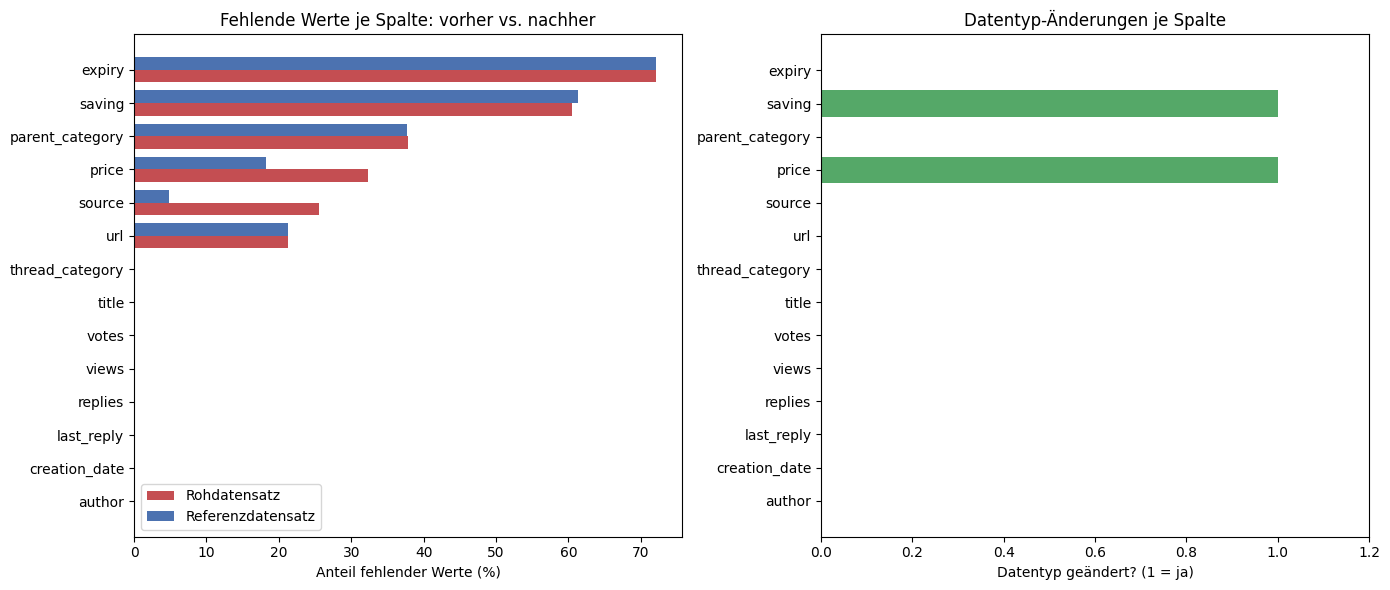

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order = comparison.sort_values("fehlend_raw_pct", ascending=True).index
x = np.arange(len(order))
width = 0.38
axes[0].barh(x - width/2, comparison.loc[order, "fehlend_raw_pct"], height=width, label="Rohdatensatz", color="#C44E52")
axes[0].barh(x + width/2, comparison.loc[order, "fehlend_clean_pct"], height=width, label="Referenzdatensatz", color="#4C72B0")
axes[0].set_yticks(x)
axes[0].set_yticklabels(order)
axes[0].set_xlabel("Anteil fehlender Werte (%)")
axes[0].set_title("Fehlende Werte je Spalte: vorher vs. nachher")
axes[0].legend()

dtype_changed = comparison["dtype_geaendert"].astype(int)
axes[1].barh(x, dtype_changed.loc[order], color="#55A868")
axes[1].set_yticks(x)
axes[1].set_yticklabels(order)
axes[1].set_xlabel("Datentyp geändert? (1 = ja)")
axes[1].set_title("Datentyp-Änderungen je Spalte")
axes[1].set_xlim(0, 1.2)

plt.tight_layout()
plt.show()


## 4. Vertiefung: `source` - automatische Ableitung aus der URL-Domain

Die zusammenfassende Tabelle oben zeigt für `source` einen auffälligen Rückgang der
fehlenden Werte. Das ist die einzige Spalte, in der der Referenzdatensatz eine echte
**Vervollständigung** (nicht nur eine Formatänderung) vorgenommen hat. Der folgende
Code belegt den Mechanismus dahinter: Wo im Rohdatensatz `source` fehlte, aber `url`
vorhanden war, wurde der Domainname aus der URL als `source`-Wert übernommen.


In [5]:
r = df_raw[["row_id", "source", "url", "title"]].rename(columns={"source": "source_raw", "url": "url_raw"})
c = df_clean[["row_id", "source"]].rename(columns={"source": "source_clean"})
m = row_mapping.merge(r, left_on="row_id_raw", right_on="row_id").merge(c, left_on="row_id_clean", right_on="row_id")

filled = m[m["source_raw"].isna() & m["source_clean"].notna()]
print(f"source: im Rohdatensatz fehlend, im Referenzdatensatz gefuellt: {len(filled)} von "
      f"{m['source_raw'].isna().sum()} fehlenden Zeilen ({len(filled) / m['source_raw'].isna().sum():.1%})")
print(f"davon mit vorhandener url (Beleg fuer URL-Domain-Ableitung): {filled['url_raw'].notna().sum()} von {len(filled)} "
      f"({filled['url_raw'].notna().mean():.1%})")
print()
filled[["title", "url_raw", "source_clean"]].head(8)


source: im Rohdatensatz fehlend, im Referenzdatensatz gefuellt: 262 von 325 fehlenden Zeilen (80.6%)
davon mit vorhandener url (Beleg fuer URL-Domain-Ableitung): 249 von 262 (95.0%)



,title,url_raw,source_clean
2,Kits.com Free Pair Prescription Glasses,https://www.kits.com/freeglasses.html,Kits
6,Oakley Men’s Super Coil Sandal 2.0 Sandals $27...,http://go.redirectingat.com?id=2927x594702&amp...,Redirectingat
10,100mb cable internet 39$,https://www.ivctel.com/Internet/Plan,Ivctel
12,"[Visions] Samsung 65"" Q80T (2020) QLED at $1998",https://www.visions.ca/product-detail/55540/sa...,Samsung
24,"Olympic 2"" weight plates - 2.5lbs ($4.05), 5lb...",http://www.amazon.ca/gp/redirect.html?ie=UTF8&...,Amazon
26,Oxio - cable internet service in QC : 15/10 $3...,https://oxio.ca/internet/,Oxio
36,AGO - free annual pass for front line workers,https://twitter.com/agotoronto/status/12837638...,Twitter
42,Bosch core battery 6.3ah 18V 90$,https://www.outilspierreberger.com/en/18-volts...,Outilspierreberger


**Interpretation:** In 249 von 262 gefüllten Fällen (95 %) lässt sich der neue
`source`-Wert direkt aus der Domain der `url`-Spalte ableiten (z. B. `kits.com` ->
`Kits`, `oxio.ca` -> `Oxio`). Diese Beobachtung relativiert die in Abschnitt 3.2
zunächst pauschal formulierte These "die Referenzbereinigung behebt ausschließlich
Formatierungsfehler" - bei `source` liegt zusätzlich eine (regelbasierte, aus einer
anderen Spalte abgeleitete) Vervollständigung vor. Für die anderen drei Fehlerarten
(Duplikate, generische fehlende Werte bei `price`/`parent_category`, semantische
Heterogenität) bleibt der Befund unverändert: Sie wurden nicht behoben.


## 5. Vertiefung: `saving` - Formatwechsel *und* abgeleitetes Verhältnis

Anders als bei den Datumsspalten (reine Syntaxnormalisierung) ist die Transformation
von `saving` **nicht** umkehrbar eindeutig aus dem Rohwert allein: Der bereinigte Wert
ist ein berechnetes Verhältnis (`saving_ratio`), das zusätzlich den bereinigten `price`
derselben Zeile benötigt (vgl. `Forschungsfrage_3_Formatierung_XGBoost_Parser.ipynb`,
Abschnitt 4).


In [6]:
r2 = df_raw[["row_id", "saving", "price"]].rename(columns={"saving": "saving_raw", "price": "price_raw"})
c2 = df_clean[["row_id", "saving", "price"]].rename(columns={"saving": "saving_clean", "price": "price_clean"})
m2 = row_mapping.merge(r2, left_on="row_id_raw", right_on="row_id").merge(c2, left_on="row_id_clean", right_on="row_id")
both2 = m2["saving_raw"].notna() & m2["saving_clean"].notna()

sample = m2.loc[both2, ["saving_raw", "price_raw", "saving_clean", "price_clean"]].head(6).copy()
sample["rekonstruiert (amount / (price_clean + amount))"] = sample.apply(
    lambda row: None if "%" in str(row["saving_raw"]) else
    (pd.to_numeric(pd.Series(str(row["saving_raw"])).str.extract(r"(\d+(?:\.\d+)?)")[0], errors="coerce").iloc[0] /
     (row["price_clean"] + pd.to_numeric(pd.Series(str(row["saving_raw"])).str.extract(r"(\d+(?:\.\d+)?)")[0], errors="coerce").iloc[0])),
    axis=1)
sample


,saving_raw,price_raw,saving_clean,price_clean,rekonstruiert (amount / (price_clean + amount))
6,50% +4%CB,27.50,0.500000,27.50,NaN
7,$119.60,278.40,0.300503,278.40,0.300503
12,600 off,1998,0.230947,1998.00,0.230947
14,$43.74,$596.25,0.068345,596.25,0.068345
15,20%,39.99,0.200000,39.99,NaN
17,Reg: $65+,$24.99,0.722302,24.99,0.722302


**Beobachtung:** Die letzte Spalte (händisch nach der Formel rekonstruiert) stimmt
mit `saving_clean` überein - das bestätigt die in Kapitel 4.3.2 dokumentierte
Ableitungsformel anhand unabhängiger Stichproben erneut.

## 6. Vertiefung: Datumsspalten - reine Formatnormalisierung ohne Vervollständigung

Im Gegensatz zu `saving` ist die Transformation der drei Datumsspalten eine
**verlustfreie, eindeutige** Syntaxnormalisierung: derselbe Zeitpunkt, nur einheitlich
geschrieben. Die Vollständigkeit (Anteil fehlender Werte) bleibt dabei unverändert.


In [7]:
for col in ["creation_date", "expiry", "last_reply"]:
    print(f"{col:15s}: fehlend raw={df_raw[col].isna().mean():.1%}  fehlend clean={df_clean[col].isna().mean():.1%}  "
          f"(Aenderung: {(df_clean[col].isna().mean() - df_raw[col].isna().mean())*100:+.1f} Prozentpunkte)")


creation_date  : fehlend raw=0.0%  fehlend clean=0.0%  (Aenderung: +0.0 Prozentpunkte)
expiry         : fehlend raw=72.1%  fehlend clean=72.1%  (Aenderung: -0.0 Prozentpunkte)
last_reply     : fehlend raw=0.0%  fehlend clean=0.0%  (Aenderung: +0.0 Prozentpunkte)


## 7. Fazit: Klassifikation aller 14 Spalten

Zusammenfassend lässt sich jede Spalte in eine von vier Kategorien einordnen:
- **unverändert**: identischer Wert, identischer Typ, identische Vollständigkeit
- **nur Formatierung**: Wert syntaktisch verändert, aber informationsgleich, Vollständigkeit unverändert
- **teilweise vervollständigt**: Anteil fehlender Werte spürbar gesunken
- **Formatierung + Vervollständigung**: beides gleichzeitig


In [8]:
def classify(row):
    missing_drop_pp = row["fehlend_raw_pct"] - row["fehlend_clean_pct"]
    format_changed = row["dtype_geaendert"] or (row["string_identisch_pct"] is not None and row["string_identisch_pct"] < 99.5)
    completed = missing_drop_pp >= 3.0  # spuerbarer Rueckgang der Fehlquote (Prozentpunkte)
    if not format_changed and not completed:
        return "unveraendert"
    if format_changed and not completed:
        return "nur Formatierung"
    if not format_changed and completed:
        return "teilweise vervollstaendigt"
    return "Formatierung + Vervollstaendigung"

comparison["Klassifikation"] = comparison.apply(classify, axis=1)
result = comparison[["dtype_raw", "dtype_clean", "fehlend_raw_pct", "fehlend_clean_pct",
                      "string_identisch_pct", "Klassifikation"]]
result


,dtype_raw,dtype_clean,fehlend_raw_pct,fehlend_clean_pct,string_identisch_pct,Klassifikation
Spalte,,,,,,
author,str,str,0.0,0.0,100.0,unveraendert
creation_date,str,str,0.0,0.0,0.0,nur Formatierung
expiry,str,str,72.1,72.1,0.0,nur Formatierung
last_reply,str,str,0.0,0.0,0.0,nur Formatierung
parent_category,str,str,37.8,37.7,100.0,unveraendert
price,str,float64,32.3,18.2,42.6,Formatierung + Vervollstaendigung
replies,int64,int64,0.0,0.0,100.0,unveraendert
saving,str,float64,60.5,61.4,0.0,nur Formatierung
source,str,str,25.6,4.8,100.0,teilweise vervollstaendigt


In [9]:
print(result["Klassifikation"].value_counts())
print()
for kategorie, gruppe in result.groupby("Klassifikation"):
    print(f"{kategorie}: {', '.join(gruppe.index)}")


Klassifikation
unveraendert                         8
nur Formatierung                     4
Formatierung + Vervollstaendigung    1
teilweise vervollstaendigt           1
Name: count, dtype: int64

Formatierung + Vervollstaendigung: price
nur Formatierung: creation_date, expiry, last_reply, saving
teilweise vervollstaendigt: source
unveraendert: author, parent_category, replies, thread_category, title, url, views, votes


**Gesamtfazit:** Von 14 Spalten bleiben 8 vollständig unverändert
(`author`, `parent_category`, `replies`, `thread_category`, `title`, `url`, `views`,
`votes`). Vier Spalten wurden ausschließlich umformatiert, ohne dass sich ihre
Vollständigkeit verbessert hätte (`creation_date`, `expiry`, `last_reply`, `saving`).
Nur zwei Spalten zeigen eine (teilweise) echte Vervollständigung: `price` (Formatierung
*und* Teil-Vervollständigung) und `source` (überwiegend Vervollständigung, keine
Formatierungsänderung nötig, da bereits als Klartext vorliegend). Dieses Muster
bestätigt und präzisiert die in Abschnitt 3.2 der Arbeit getroffene Einschätzung: Die
Referenzbereinigung ist selektiv und deckt die vier in dieser Arbeit untersuchten
Fehlerarten nur sehr ungleichmäßig ab - was die eigenständige Konstruktion
kontrollierter Benchmarks (vgl. `01_Benchmark_und_GroundTruth_Erstellung.ipynb`) für
Duplikate und generische fehlende Werte notwendig macht.
